In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from utils import load_pickle_file

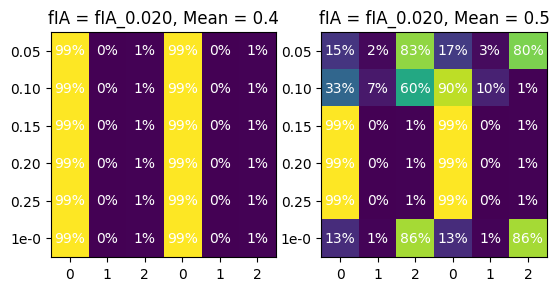

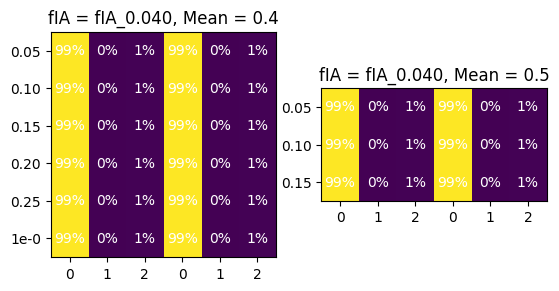

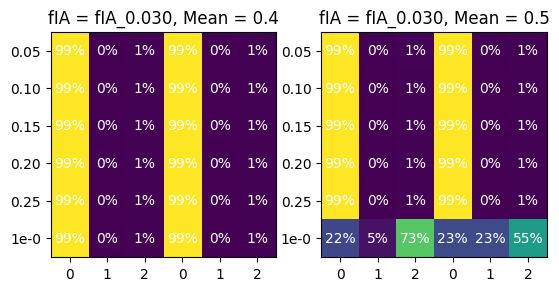

In [2]:
base_dir = "em_results/wiki/threshold_norm"

x_ticks = [0,1,2,0,1,2]

for fIA in os.listdir(base_dir):
    means = set()
    for subdir in os.listdir(os.path.join(base_dir, fIA)):
        parts = subdir.split('_')
        mean_value = float(parts[1])
        means.add(mean_value)
    
    fig, axes = plt.subplots(1, 2)
    axes.flatten()
    for n, mean in dict(enumerate(sorted(means))).items():
        results , stds= [], []
        subdirs = [os.path.join(base_dir, fIA, subdir) for subdir in os.listdir(os.path.join(base_dir, fIA)) if subdir.startswith(f"mean_{mean}")]
        subdirs = sorted(subdirs)
        for subdir in subdirs:
            parts = subdir.split('_')
            std = parts[len(parts) - 1]
            stds.append(std[:4])

            file_paths = [os.path.join(subdir, f) for f in os.listdir(subdir)]

            recency_worse_counts = defaultdict(int)
            frequency_worse_counts = defaultdict(int)

            total_nodes_set = set()

            for path in file_paths:
                em_data = load_pickle_file(path)

                node_ids = em_data["nodeID"]
                rec = em_data["em_recency"]
                freq = em_data["em_frequency"]

                for node, r, f in zip(node_ids, rec, freq):
                    total_nodes_set.add(node)

                    if r < 1:
                        recency_worse_counts[node] += 1
                    if f < 1:
                        frequency_worse_counts[node] += 1

            total_nodes = len(total_nodes_set)

            n_methods = len(file_paths)

            # --- Tally number of nodes in 0, 1, or 2 methods worse off ---
            recency_dist = [0] * (n_methods + 1)
            frequency_dist = [0] * (n_methods + 1)

            for node in total_nodes_set:
                recency_dist[recency_worse_counts[node]] += 1
                frequency_dist[frequency_worse_counts[node]] += 1

            recency_dist = [x / total_nodes for x in recency_dist]
            frequency_dist = [x / total_nodes for x in frequency_dist]

            results.append(recency_dist + frequency_dist)
    
        im = axes[n].imshow(results)
        
        axes[n].set_yticks(range(len(stds)), labels=stds)
        axes[n].set_xticks(range(len(x_ticks)), labels=x_ticks)

        for i in range(len(stds)):
            for j in range(len(x_ticks)):
                text = axes[n].text(j, i, f"{round(results[i][j], 3):.0%}",
                            ha="center", va="center", color="w")

        axes[n].set_title(f"fIA = {fIA}, Mean = {mean}")
    plt.show()

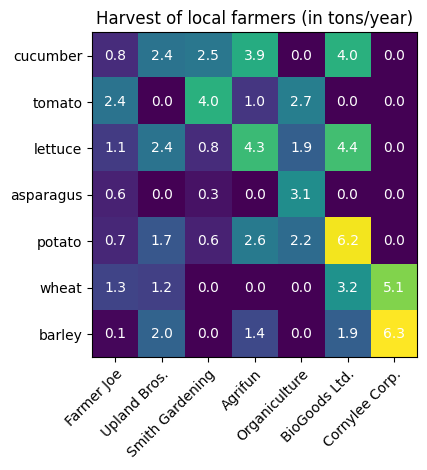

In [25]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib
import matplotlib as mpl


vegetables = ["cucumber", "tomato", "lettuce", "asparagus",
              "potato", "wheat", "barley"]
farmers = ["Farmer Joe", "Upland Bros.", "Smith Gardening",
           "Agrifun", "Organiculture", "BioGoods Ltd.", "Cornylee Corp."]

harvest = np.array([[0.8, 2.4, 2.5, 3.9, 0.0, 4.0, 0.0],
                    [2.4, 0.0, 4.0, 1.0, 2.7, 0.0, 0.0],
                    [1.1, 2.4, 0.8, 4.3, 1.9, 4.4, 0.0],
                    [0.6, 0.0, 0.3, 0.0, 3.1, 0.0, 0.0],
                    [0.7, 1.7, 0.6, 2.6, 2.2, 6.2, 0.0],
                    [1.3, 1.2, 0.0, 0.0, 0.0, 3.2, 5.1],
                    [0.1, 2.0, 0.0, 1.4, 0.0, 1.9, 6.3]])


fig, ax = plt.subplots()
im = ax.imshow(harvest)

# Show all ticks and label them with the respective list entries
ax.set_xticks(range(len(farmers)), labels=farmers,
              rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticks(range(len(vegetables)), labels=vegetables)

# Loop over data dimensions and create text annotations.
for i in range(len(vegetables)):
    for j in range(len(farmers)):
        text = ax.text(j, i, harvest[i, j],
                       ha="center", va="center", color="w")

ax.set_title("Harvest of local farmers (in tons/year)")
fig.tight_layout()
plt.show()